<a href="https://colab.research.google.com/github/SenTier1107/DataManagement_2026/blob/main/%EB%8D%B0%EC%9D%B4%ED%84%B0%EA%B4%80%EB%A6%AC%EB%A1%A0_2026_04_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 4주차 데이터관리론 - Colab 실습
## 조건부 확률, 베이즈 정리, 나이브 베이즈, Long-Tail Distribution
---

In [1]:
# 필요한 라이브러리 설치 및 임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (Colab용)
!sudo apt-get install -y fonts-nanum > /dev/null 2>&1
import matplotlib.font_manager as fm

# 폰트 캐시 재빌드
fm._load_fontmanager(try_read_cache=False)

matplotlib.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

print('라이브러리 로드 완료!')

라이브러리 로드 완료!


---
## 1. 조건부 확률 시각화 (슬라이드 46~47)
### Hexbin with Marginal Distribution + Conditional Distribution

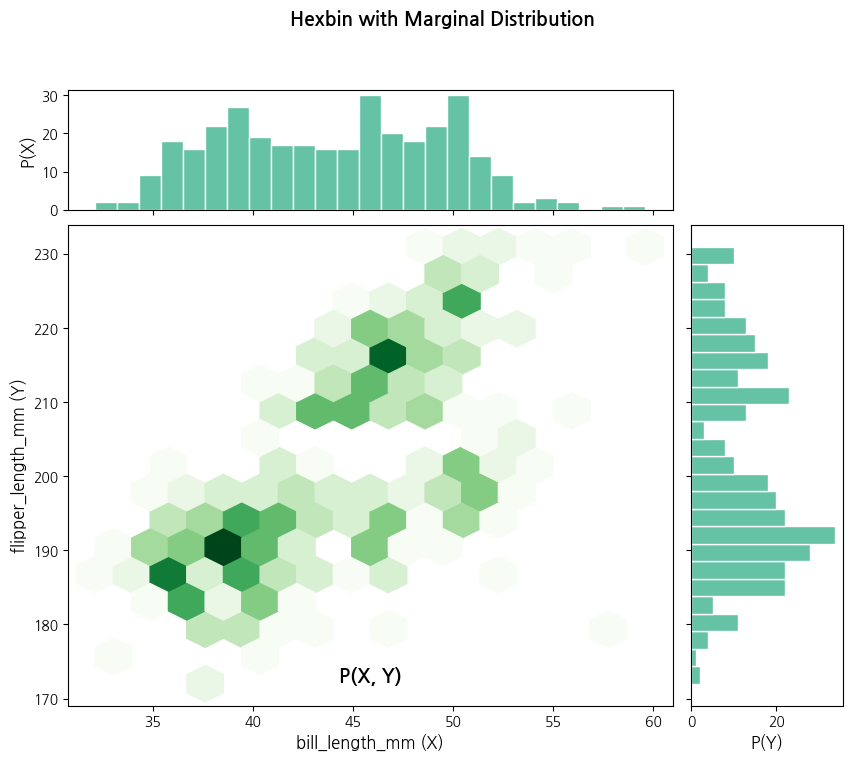

In [2]:
import seaborn as sns

# 펭귄 데이터셋 로드
penguins = sns.load_dataset('penguins').dropna()

X = penguins['bill_length_mm']
Y = penguins['flipper_length_mm']

# ── 1-1) Hexbin + Marginal Distribution ──
fig = plt.figure(figsize=(10, 8))
gs = fig.add_gridspec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
                      hspace=0.05, wspace=0.05)

ax_main = fig.add_subplot(gs[1, 0])
ax_top = fig.add_subplot(gs[0, 0], sharex=ax_main)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

# 결합 분포 P(X, Y) - hexbin
hb = ax_main.hexbin(X, Y, gridsize=15, cmap='Greens', mincnt=1)
ax_main.set_xlabel('bill_length_mm (X)', fontsize=12)
ax_main.set_ylabel('flipper_length_mm (Y)', fontsize=12)
ax_main.text(0.5, 0.05, 'P(X, Y)', transform=ax_main.transAxes,
             fontsize=14, fontweight='bold', ha='center')

# 주변 분포 P(X)
ax_top.hist(X, bins=25, color='#66c2a5', edgecolor='white')
ax_top.set_ylabel('P(X)', fontsize=12)
plt.setp(ax_top.get_xticklabels(), visible=False)

# 주변 분포 P(Y)
ax_right.hist(Y, bins=25, orientation='horizontal', color='#66c2a5', edgecolor='white')
ax_right.set_xlabel('P(Y)', fontsize=12)
plt.setp(ax_right.get_yticklabels(), visible=False)

fig.suptitle('Hexbin with Marginal Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

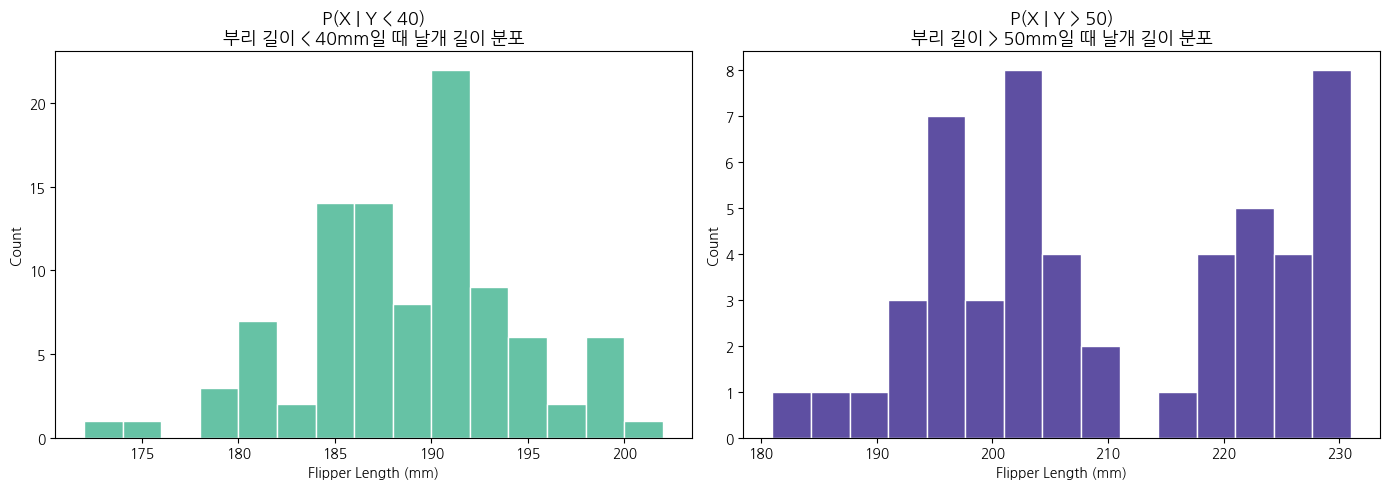

부리 < 40mm: 날개 평균 = 188.4mm, 표준편차 = 5.6mm
부리 > 50mm: 날개 평균 = 209.7mm, 표준편차 = 14.0mm

→ 부리가 긴 펭귄은 날개도 길고, 분포 범위도 넓다.


In [3]:
# ── 1-2) 조건부 확률 히스토그램 ──
# 부리 길이(Y) < 40 vs Y > 50 일 때 날개 길이(X)의 조건부 분포

cond_short = penguins[penguins['bill_length_mm'] < 40]['flipper_length_mm']
cond_long = penguins[penguins['bill_length_mm'] > 50]['flipper_length_mm']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(cond_short, bins=15, color='#66c2a5', edgecolor='white')
axes[0].set_title('P(X | Y < 40)\n부리 길이 < 40mm일 때 날개 길이 분포', fontsize=13)
axes[0].set_xlabel('Flipper Length (mm)')
axes[0].set_ylabel('Count')

axes[1].hist(cond_long, bins=15, color='#5e4fa2', edgecolor='white')
axes[1].set_title('P(X | Y > 50)\n부리 길이 > 50mm일 때 날개 길이 분포', fontsize=13)
axes[1].set_xlabel('Flipper Length (mm)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"부리 < 40mm: 날개 평균 = {cond_short.mean():.1f}mm, 표준편차 = {cond_short.std():.1f}mm")
print(f"부리 > 50mm: 날개 평균 = {cond_long.mean():.1f}mm, 표준편차 = {cond_long.std():.1f}mm")
print("\n→ 부리가 긴 펭귄은 날개도 길고, 분포 범위도 넓다.")

---
## 2. 베이즈 정리 - 금융업 종사자 문제 (슬라이드 48~49)
### 넥타이를 맨 남자가 금융 및 보험업에 종사할 사후확률

In [4]:
# ── 주어진 데이터 ──
total_workers = 6_246_489
finance_workers = 66_014
other_workers = total_workers - finance_workers

# 사전확률
P_finance = finance_workers / total_workers
P_other = other_workers / total_workers

# 넥타이 착용률 (Evidence / Likelihood)
P_tie_given_finance = 0.90
P_tie_given_other = 0.15

# ── 베이즈 정리 계산 ──
# P(넥타이) = P(넥타이|금융) * P(금융) + P(넥타이|기타) * P(기타)
P_tie = P_tie_given_finance * P_finance + P_tie_given_other * P_other

# P(금융|넥타이) = P(넥타이|금융) * P(금융) / P(넥타이)
P_finance_given_tie = (P_tie_given_finance * P_finance) / P_tie

# ── 결과 표시 ──
print("="*60)
print("금융업 종사자 베이즈 정리 문제")
print("="*60)
print(f"\n[사전확률]")
print(f"  P(금융업) = {finance_workers:,} / {total_workers:,} = {P_finance:.4%}")
print(f"  P(기타)  = {other_workers:,} / {total_workers:,} = {P_other:.4%}")
print(f"\n[우도 (Likelihood)]")
print(f"  P(넥타이 | 금융업) = {P_tie_given_finance:.0%}")
print(f"  P(넥타이 | 기타)  = {P_tie_given_other:.0%}")
print(f"\n[증거 (Evidence)]")
print(f"  P(넥타이) = {P_tie_given_finance} × {P_finance:.6f} + {P_tie_given_other} × {P_other:.6f}")
print(f"           = {P_tie:.6f}")
print(f"\n[사후확률 (Posterior)]")
print(f"  P(금융업 | 넥타이) = {P_finance_given_tie:.4%}")

# ── 수치 검증 테이블 (슬라이드 49) ──
tie_finance = int(finance_workers * P_tie_given_finance)
tie_other = int(other_workers * P_tie_given_other)
tie_total = tie_finance + tie_other

print(f"\n[검증 테이블]")
df_table = pd.DataFrame({
    '총 사업자수': [total_workers, finance_workers, other_workers],
    '넥타이 착용자': [tie_total, tie_finance, tie_other],
    '착용률': ['', '90%', '15%']
}, index=['총 인구', '금융업', '다른 업종'])
print(df_table)
print(f"\n사전확률 {P_finance:.2%} → 사후확률 {P_finance_given_tie:.2%} (넥타이 착용 증거 반영)")

금융업 종사자 베이즈 정리 문제

[사전확률]
  P(금융업) = 66,014 / 6,246,489 = 1.0568%
  P(기타)  = 6,180,475 / 6,246,489 = 98.9432%

[우도 (Likelihood)]
  P(넥타이 | 금융업) = 90%
  P(넥타이 | 기타)  = 15%

[증거 (Evidence)]
  P(넥타이) = 0.9 × 0.010568 + 0.15 × 0.989432
           = 0.157926

[사후확률 (Posterior)]
  P(금융업 | 넥타이) = 6.0227%

[검증 테이블]
        총 사업자수  넥타이 착용자  착용률
총 인구   6246489   986483     
금융업      66014    59412  90%
다른 업종  6180475   927071  15%

사전확률 1.06% → 사후확률 6.02% (넥타이 착용 증거 반영)


---
## 3. 베이즈 정리 - 택시 문제 (슬라이드 50~52)
### 뺑소니 택시 색상 판별

In [5]:
# ── 주어진 데이터 ──
P_blue = 0.15      # 청색 택시 비율
P_green = 0.85     # 녹색 택시 비율
accuracy = 0.80    # 목격자 판별 정확도

# ── 트리 구조 계산 ──
# 청색 택시 + 정답 (청색이라 증언) = 0.15 * 0.80
P_witness_blue_and_blue = P_blue * accuracy
# 청색 택시 + 오답 (녹색이라 증언) = 0.15 * 0.20
P_witness_green_and_blue = P_blue * (1 - accuracy)
# 녹색 택시 + 정답 (녹색이라 증언) = 0.85 * 0.80
P_witness_green_and_green = P_green * accuracy
# 녹색 택시 + 오답 (청색이라 증언) = 0.85 * 0.20
P_witness_blue_and_green = P_green * (1 - accuracy)

# ── 전체 청색 증언 확률 P(W_B) ──
P_witness_blue = P_witness_blue_and_blue + P_witness_blue_and_green

# ── 사후확률: P(T_B | W_B) ──
P_blue_given_witness = P_witness_blue_and_blue / P_witness_blue

print("="*60)
print("택시 뺑소니 문제 - 베이즈 정리")
print("="*60)
print(f"\n[사건 정의]")
print(f"  T_B: 실제 청색 택시, T_G: 실제 녹색 택시")
print(f"  W_B: 목격자가 '청색'이라 증언")
print(f"\n[사전확률]")
print(f"  P(T_B) = {P_blue}")
print(f"  P(T_G) = {P_green}")
print(f"\n[조건부 확률 (Likelihood)]")
print(f"  P(W_B | T_B) = {accuracy}  (실제 청색 → 청색 증언)")
print(f"  P(W_B | T_G) = {1-accuracy}  (실제 녹색 → 청색 증언, 오판)")
print(f"\n[트리 분석 (100건 가정)]")
print(f"  청색택시(15건) → 정답(80%) → {P_witness_blue_and_blue*100:.0f}건 청색 증언")
print(f"  청색택시(15건) → 오답(20%) → {P_witness_green_and_blue*100:.0f}건 녹색 증언")
print(f"  녹색택시(85건) → 정답(80%) → {P_witness_green_and_green*100:.0f}건 녹색 증언")
print(f"  녹색택시(85건) → 오답(20%) → {P_witness_blue_and_green*100:.0f}건 청색 증언")
print(f"\n[증거 확률]")
print(f"  P(W_B) = {P_witness_blue_and_blue} + {P_witness_blue_and_green} = {P_witness_blue}")
print(f"\n[사후확률]")
print(f"  P(T_B | W_B) = {P_witness_blue_and_blue} / {P_witness_blue} ≈ {P_blue_given_witness:.4f}")
print(f"\n→ 목격자가 청색이라 했지만, 실제 청색일 확률은 약 {P_blue_given_witness:.1%}에 불과!")

택시 뺑소니 문제 - 베이즈 정리

[사건 정의]
  T_B: 실제 청색 택시, T_G: 실제 녹색 택시
  W_B: 목격자가 '청색'이라 증언

[사전확률]
  P(T_B) = 0.15
  P(T_G) = 0.85

[조건부 확률 (Likelihood)]
  P(W_B | T_B) = 0.8  (실제 청색 → 청색 증언)
  P(W_B | T_G) = 0.19999999999999996  (실제 녹색 → 청색 증언, 오판)

[트리 분석 (100건 가정)]
  청색택시(15건) → 정답(80%) → 12건 청색 증언
  청색택시(15건) → 오답(20%) → 3건 녹색 증언
  녹색택시(85건) → 정답(80%) → 68건 녹색 증언
  녹색택시(85건) → 오답(20%) → 17건 청색 증언

[증거 확률]
  P(W_B) = 0.12 + 0.16999999999999996 = 0.2899999999999999

[사후확률]
  P(T_B | W_B) = 0.12 / 0.2899999999999999 ≈ 0.4138

→ 목격자가 청색이라 했지만, 실제 청색일 확률은 약 41.4%에 불과!


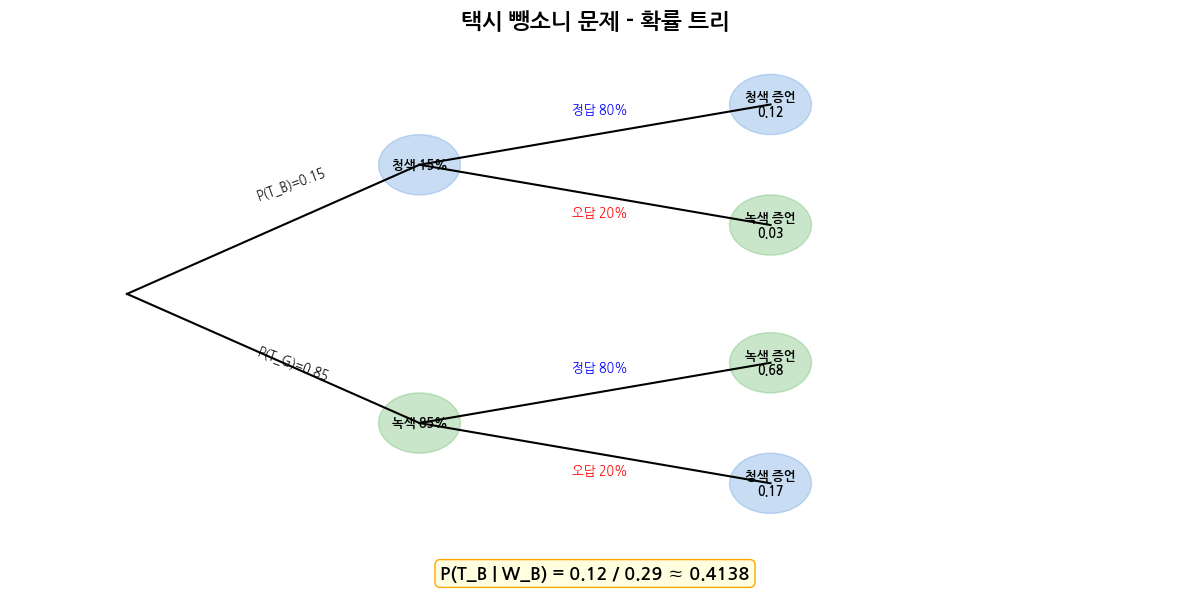

In [6]:
# ── 택시 문제 시각화: 트리 다이어그램 ──
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis('off')
ax.set_title('택시 뺑소니 문제 - 확률 트리', fontsize=16, fontweight='bold')

# 노드 위치
root = (1, 3)
blue_node = (3.5, 4.5)
green_node = (3.5, 1.5)

blue_correct = (6.5, 5.2)
blue_wrong = (6.5, 3.8)
green_correct = (6.5, 2.2)
green_wrong = (6.5, 0.8)

# 선 그리기
for start, end in [(root, blue_node), (root, green_node),
                   (blue_node, blue_correct), (blue_node, blue_wrong),
                   (green_node, green_correct), (green_node, green_wrong)]:
    ax.plot([start[0], end[0]], [start[1], end[1]], 'k-', lw=1.5)

# 노드
for pos, color, label in [
    (blue_node, '#4a90d9', '청색 15%'),
    (green_node, '#4CAF50', '녹색 85%'),
    (blue_correct, '#4a90d9', f'청색 증언\n{P_witness_blue_and_blue:.2f}'),
    (blue_wrong, '#4CAF50', f'녹색 증언\n{P_witness_green_and_blue:.2f}'),
    (green_correct, '#4CAF50', f'녹색 증언\n{P_witness_green_and_green:.2f}'),
    (green_wrong, '#4a90d9', f'청색 증언\n{P_witness_blue_and_green:.2f}')
]:
    ax.add_patch(plt.Circle(pos, 0.35, color=color, alpha=0.3))
    ax.text(pos[0], pos[1], label, ha='center', va='center', fontsize=9, fontweight='bold')

# 엣지 라벨
ax.text(2.1, 4.1, 'P(T_B)=0.15', fontsize=9, rotation=20)
ax.text(2.1, 2.0, 'P(T_G)=0.85', fontsize=9, rotation=-20)
ax.text(4.8, 5.1, '정답 80%', fontsize=9, color='blue')
ax.text(4.8, 3.9, '오답 20%', fontsize=9, color='red')
ax.text(4.8, 2.1, '정답 80%', fontsize=9, color='blue')
ax.text(4.8, 0.9, '오답 20%', fontsize=9, color='red')

# 결과 박스
result_text = f'P(T_B | W_B) = 0.12 / 0.29 ≈ {P_blue_given_witness:.4f}'
ax.text(5, -0.3, result_text, fontsize=13, fontweight='bold',
        ha='center', bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='orange'))

plt.tight_layout()
plt.show()

---
## 4. 베이즈 정리 - 식중독 문제 (슬라이드 53~54)
### 식중독 걸린 학생이 식당 B에서 먹었을 확률

In [7]:
# ── 주어진 데이터 ──
P_A = 0.60   # 식당 A 방문 확률
P_B = 0.40   # 식당 B 방문 확률
P_F_A = 0.01 # 식당 A 식중독 확률
P_F_B = 0.05 # 식당 B 식중독 확률

# ── Step 1: 전체 식중독 발생 확률 P(F) ──
P_F = P_A * P_F_A + P_B * P_F_B

# ── Step 2: 베이즈 정리 P(B|F) ──
P_B_given_F = (P_B * P_F_B) / P_F
P_A_given_F = (P_A * P_F_A) / P_F

print("="*60)
print("식중독 문제 - 베이즈 정리")
print("="*60)
print(f"\n[사건 정의]")
print(f"  A: 식당 A에서 식사, B: 식당 B에서 식사, F: 식중독")
print(f"\n[주어진 확률]")
print(f"  P(A) = {P_A}, P(B) = {P_B}")
print(f"  P(F|A) = {P_F_A}, P(F|B) = {P_F_B}")
print(f"\n[Step 1] 전체 식중독 확률 P(F)")
print(f"  P(F) = P(A)×P(F|A) + P(B)×P(F|B)")
print(f"       = {P_A}×{P_F_A} + {P_B}×{P_F_B}")
print(f"       = {P_A*P_F_A} + {P_B*P_F_B} = {P_F}")
print(f"\n[Step 2] 베이즈 정리")
print(f"  P(B|F) = P(B)×P(F|B) / P(F)")
print(f"         = {P_B*P_F_B} / {P_F}")
print(f"         = {P_B_given_F:.6f}")
print(f"         = 20/26 = 10/13 ≈ {10/13:.4f}")
print(f"\n→ 식중독에 걸렸을 때, 식당 B에서 식사했을 확률: {P_B_given_F:.1%}")
print(f"  (참고: 식당 A였을 확률: {P_A_given_F:.1%})")

식중독 문제 - 베이즈 정리

[사건 정의]
  A: 식당 A에서 식사, B: 식당 B에서 식사, F: 식중독

[주어진 확률]
  P(A) = 0.6, P(B) = 0.4
  P(F|A) = 0.01, P(F|B) = 0.05

[Step 1] 전체 식중독 확률 P(F)
  P(F) = P(A)×P(F|A) + P(B)×P(F|B)
       = 0.6×0.01 + 0.4×0.05
       = 0.006 + 0.020000000000000004 = 0.026000000000000002

[Step 2] 베이즈 정리
  P(B|F) = P(B)×P(F|B) / P(F)
         = 0.020000000000000004 / 0.026000000000000002
         = 0.769231
         = 20/26 = 10/13 ≈ 0.7692

→ 식중독에 걸렸을 때, 식당 B에서 식사했을 확률: 76.9%
  (참고: 식당 A였을 확률: 23.1%)


---
## 5. Survivorship Bias - 비행기 문제 (슬라이드 55)
### 동체 손상 귀환 확률 P(귀환|동체손상)

In [8]:
# ── 모의 실험 결과 자료 ──
data = {
    '손상부위': ['엔진', '조종석', '동체', '앞날개', '없음'],
    '귀환(총 316기)': [29, 36, 50, 55, 146],
    '격추(총 60기)': [31, 21, 4, 4, 0]
}
df_plane = pd.DataFrame(data)
df_plane['합계'] = df_plane['귀환(총 316기)'] + df_plane['격추(총 60기)']
df_plane['귀환율'] = df_plane['귀환(총 316기)'] / df_plane['합계']

print("="*60)
print("Survivorship Bias - 비행기 귀환 확률")
print("="*60)
print()
print(df_plane.to_string(index=False))

# P(귀환|동체손상)
body_return = 50
body_total = 50 + 4
P_return_body = body_return / body_total

print(f"\n[핵심 계산]")
print(f"  P(귀환|동체손상) = {body_return} / {body_total} = {P_return_body:.4f} ({P_return_body:.1%})")
print(f"\n[해석]")
print(f"  동체가 손상되어도 귀환 확률이 {P_return_body:.1%}로 매우 높음")
print(f"  반면 엔진 손상 귀환율 = {29/(29+31):.1%}, 조종석 손상 귀환율 = {36/(36+21):.1%}")
print(f"\n→ 생존편향: 동체에 총알 자국이 많은 건 동체 맞아도 살아남기 때문!")
print(f"  보강해야 할 부위는 오히려 엔진과 조종석!")

Survivorship Bias - 비행기 귀환 확률

손상부위  귀환(총 316기)  격추(총 60기)  합계      귀환율
  엔진          29         31  60 0.483333
 조종석          36         21  57 0.631579
  동체          50          4  54 0.925926
 앞날개          55          4  59 0.932203
  없음         146          0 146 1.000000

[핵심 계산]
  P(귀환|동체손상) = 50 / 54 = 0.9259 (92.6%)

[해석]
  동체가 손상되어도 귀환 확률이 92.6%로 매우 높음
  반면 엔진 손상 귀환율 = 48.3%, 조종석 손상 귀환율 = 63.2%

→ 생존편향: 동체에 총알 자국이 많은 건 동체 맞아도 살아남기 때문!
  보강해야 할 부위는 오히려 엔진과 조종석!


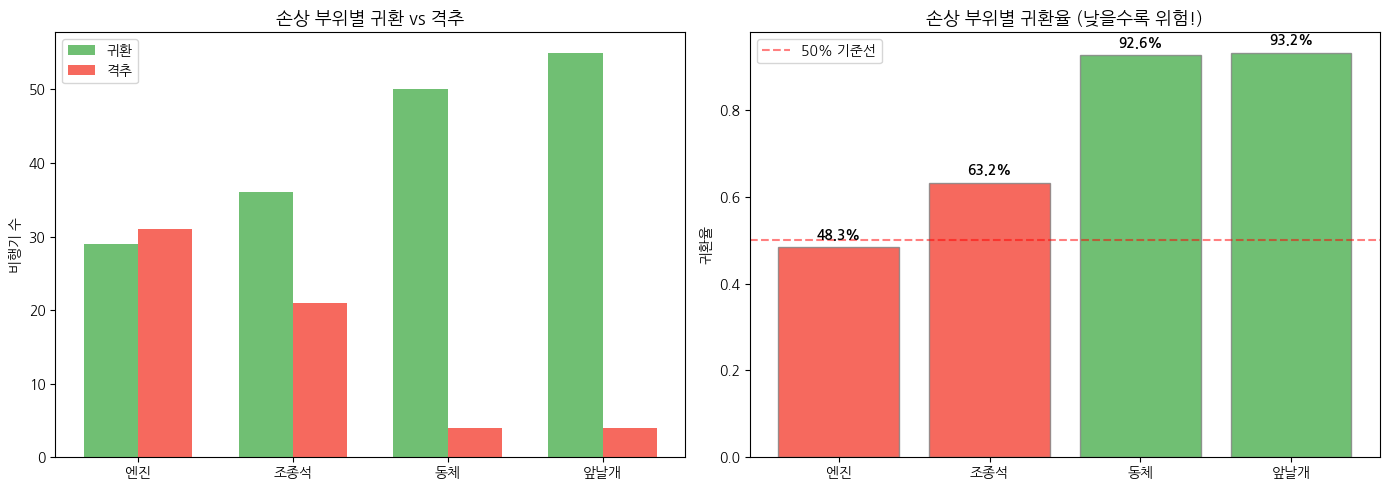

In [9]:
# ── Survivorship Bias 시각화 ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

parts = ['엔진', '조종석', '동체', '앞날개']
returns = [29, 36, 50, 55]
shot_down = [31, 21, 4, 4]

x = np.arange(len(parts))
width = 0.35

axes[0].bar(x - width/2, returns, width, label='귀환', color='#4CAF50', alpha=0.8)
axes[0].bar(x + width/2, shot_down, width, label='격추', color='#f44336', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(parts)
axes[0].set_ylabel('비행기 수')
axes[0].set_title('손상 부위별 귀환 vs 격추', fontsize=13)
axes[0].legend()

return_rates = [r/(r+s) for r, s in zip(returns, shot_down)]
colors = ['#f44336' if rate < 0.7 else '#FF9800' if rate < 0.85 else '#4CAF50'
          for rate in return_rates]
axes[1].bar(parts, return_rates, color=colors, alpha=0.8, edgecolor='gray')
axes[1].set_ylabel('귀환율')
axes[1].set_title('손상 부위별 귀환율 (낮을수록 위험!)', fontsize=13)
axes[1].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='50% 기준선')
for i, v in enumerate(return_rates):
    axes[1].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 6. 나이브 베이즈 분류기 (슬라이드 57~58)
### 엑셀 수동 계산 + scikit-learn 비교

In [10]:
from sklearn.naive_bayes import GaussianNB

# ── Training Data ──
train_data = {
    'Person': ['male','male','male','male','female','female','female','female'],
    'height': [6, 5.92, 5.58, 5.92, 5, 5.5, 5.42, 5.75],
    'weight': [180, 190, 170, 165, 100, 150, 130, 150],
    'foot_size': [12, 11, 12, 10, 6, 8, 7, 9]
}
df_train = pd.DataFrame(train_data)

# Testing Data
test_sample = [6, 130, 8]

print("="*60)
print("나이브 베이즈 분류기 - 성별 예측")
print("="*60)
print("\n[학습 데이터]")
print(df_train.to_string(index=False))
print(f"\n[테스트 데이터] height={test_sample[0]}, weight={test_sample[1]}, foot_size={test_sample[2]}")

나이브 베이즈 분류기 - 성별 예측

[학습 데이터]
Person  height  weight  foot_size
  male    6.00     180         12
  male    5.92     190         11
  male    5.58     170         12
  male    5.92     165         10
female    5.00     100          6
female    5.50     150          8
female    5.42     130          7
female    5.75     150          9

[테스트 데이터] height=6, weight=130, foot_size=8


In [11]:
# ── 방법 1: 수동 계산 (엑셀 방식) ──
print("\n" + "="*60)
print("방법 1: 수동 계산 (정규분포 가정)")
print("="*60)

male_data = df_train[df_train['Person'] == 'male']
female_data = df_train[df_train['Person'] == 'female']

# 클래스별 통계량
features = ['height', 'weight', 'foot_size']
stats_dict = {}

for gender, data in [('male', male_data), ('female', female_data)]:
    stats_dict[gender] = {}
    for feat in features:
        stats_dict[gender][feat] = {
            'mean': data[feat].mean(),
            'var': data[feat].var()  # pandas default ddof=1
        }

print("\n[클래스별 통계량 (평균 & 분산)]")
for gender in ['male', 'female']:
    print(f"\n  {gender}:")
    for feat in features:
        m = stats_dict[gender][feat]['mean']
        v = stats_dict[gender][feat]['var']
        print(f"    {feat}: μ={m:.3f}, σ²={v:.3f}")

# 정규분포 PDF 계산
def gaussian_pdf(x, mean, var):
    return (1 / np.sqrt(2 * np.pi * var)) * np.exp(-(x - mean)**2 / (2 * var))

# 사전확률
P_male = 0.5
P_female = 0.5

# 각 특성의 우도 계산
print(f"\n[우도 계산] 테스트: height={test_sample[0]}, weight={test_sample[1]}, foot={test_sample[2]}")

posterior_male = P_male
posterior_female = P_female

for i, feat in enumerate(features):
    l_male = gaussian_pdf(test_sample[i],
                          stats_dict['male'][feat]['mean'],
                          stats_dict['male'][feat]['var'])
    l_female = gaussian_pdf(test_sample[i],
                            stats_dict['female'][feat]['mean'],
                            stats_dict['female'][feat]['var'])
    posterior_male *= l_male
    posterior_female *= l_female
    print(f"  p({feat}={test_sample[i]} | male)  = {l_male:.7f}")
    print(f"  p({feat}={test_sample[i]} | female) = {l_female:.7f}")

# Softmax 정규화
total = posterior_male + posterior_female
prob_male = posterior_male / total
prob_female = posterior_female / total

print(f"\n[사후확률 (Numerator)]")
print(f"  P(male)  × Π likelihoods = {posterior_male:.10e}")
print(f"  P(female) × Π likelihoods = {posterior_female:.10e}")
print(f"\n[정규화 후 확률]")
print(f"  P(male  | data) = {prob_male:.6f} ({prob_male:.2%})")
print(f"  P(female | data) = {prob_female:.6f} ({prob_female:.2%})")
print(f"\n  ▶ 수동 계산 예측: {'여성' if prob_female > prob_male else '남성'}")


방법 1: 수동 계산 (정규분포 가정)

[클래스별 통계량 (평균 & 분산)]

  male:
    height: μ=5.855, σ²=0.035
    weight: μ=176.250, σ²=122.917
    foot_size: μ=11.250, σ²=0.917

  female:
    height: μ=5.418, σ²=0.097
    weight: μ=132.500, σ²=558.333
    foot_size: μ=7.500, σ²=1.667

[우도 계산] 테스트: height=6, weight=130, foot=8
  p(height=6 | male)  = 1.5788832
  p(height=6 | female) = 0.2234587
  p(weight=130 | male)  = 0.0000060
  p(weight=130 | female) = 0.0167893
  p(foot_size=8 | male)  = 0.0013112
  p(foot_size=8 | female) = 0.2866907

[사후확률 (Numerator)]
  P(male)  × Π likelihoods = 6.1970718439e-09
  P(female) × Π likelihoods = 5.3779091836e-04

[정규화 후 확률]
  P(male  | data) = 0.000012 (0.00%)
  P(female | data) = 0.999988 (100.00%)

  ▶ 수동 계산 예측: 여성


In [12]:
# ── 방법 2: scikit-learn GaussianNB ──
print("\n" + "="*60)
print("방법 2: scikit-learn GaussianNB")
print("="*60)

X_train = df_train[features].values
y_train = (df_train['Person'] == 'male').astype(int).values  # 1=male, 0=female

model = GaussianNB()
model.fit(X_train, y_train)

X_test = np.array([test_sample])
prediction = model.predict(X_test)
proba = model.predict_proba(X_test)

label = '남성(male)' if prediction[0] == 1 else '여성(female)'
print(f"\n  예측 결과: {label}")
print(f"  P(female) = {proba[0][0]:.6f} ({proba[0][0]:.2%})")
print(f"  P(male)   = {proba[0][1]:.6f} ({proba[0][1]:.2%})")

print(f"\n[비교]")
print(f"  수동 계산 - P(female): {prob_female:.4f}, P(male): {prob_male:.4f}")
print(f"  sklearn   - P(female): {proba[0][0]:.4f}, P(male): {proba[0][1]:.4f}")
print(f"\n  ※ 분산 계산 방식(ddof) 차이로 약간의 차이가 있을 수 있음")


방법 2: scikit-learn GaussianNB

  예측 결과: 여성(female)
  P(female) = 1.000000 (100.00%)
  P(male)   = 0.000000 (0.00%)

[비교]
  수동 계산 - P(female): 1.0000, P(male): 0.0000
  sklearn   - P(female): 1.0000, P(male): 0.0000

  ※ 분산 계산 방식(ddof) 차이로 약간의 차이가 있을 수 있음


---
## 7. Bayesian vs Frequentist (슬라이드 59~61)
### 카드 맞추기 - Stub, Freq, Bays 비교

In [13]:
print("="*60)
print("초능력자 카드 맞추기 - 세 가지 관점")
print("="*60)

# ── Stub (고정관념) ──
P_super_prior = 0.001
print(f"\n[Stub - 고정관념]")
print(f"  사전확률만 고수: P(초능력자) = {P_super_prior:.1%}")
print(f"  → 데이터 무시, 여전히 {P_super_prior:.1%}")

# ── Freq (빈도주의) ──
p_value = (1/2)**5
print(f"\n[Freq - 빈도주의]")
print(f"  일반인이 5회 연속 맞출 확률 (p-value)")
print(f"  P(5연속 정답 | 일반인) = (1/2)^5 = {p_value:.5f} = {p_value:.2%}")
print(f"  → '일반인이 운으로 맞출 확률이 {p_value:.2%}' (간접적 판단)")

# ── Bays (베이지안) ──
P_theta = 0.001          # P(초능력자)
P_not_theta = 0.999      # P(일반인)
P_5_given_super = 1.0    # 초능력자가 5개 맞출 확률
P_5_given_normal = (1/2)**5  # 일반인이 5개 맞출 확률

# P(초능력자 | 5연속 정답)
numerator = P_5_given_super * P_theta
denominator = P_5_given_super * P_theta + P_5_given_normal * P_not_theta
P_super_posterior = numerator / denominator

print(f"\n[Bays - 베이지안]")
print(f"  P(θ | 5정답) = P(5정답|θ) × P(θ) / [P(5정답|θ)×P(θ) + P(5정답|~θ)×P(~θ)]")
print(f"              = {P_5_given_super} × {P_theta} / ({P_5_given_super}×{P_theta} + {P_5_given_normal:.5f}×{P_not_theta})")
print(f"              = {numerator} / {denominator:.6f}")
print(f"              = {P_super_posterior:.6f} ≈ {P_super_posterior:.1%}")
print(f"  P(~θ | 5정답) = 1 - {P_super_posterior:.6f} = {1-P_super_posterior:.1%}")

# ── 비교 테이블 ──
print(f"\n{'='*60}")
print(f"{'이름':<8} {'유형':<10} {'계산된 확률':<12} {'핵심 논리'}")
print(f"{'-'*60}")
print(f"{'Stub':<8} {'고정관념':<10} {P_super_prior:<12.2%} {'데이터 무시, 사전확률만 고수'}")
print(f"{'Freq':<8} {'빈도주의':<10} {p_value:<12.2%} {'일반인이 이런 결과를 낼 확률(p-value)'}")
print(f"{'Bays':<8} {'베이지안':<10} {P_super_posterior:<12.2%} {'사전확률 + 증거 → 사후확률 업데이트'}")

초능력자 카드 맞추기 - 세 가지 관점

[Stub - 고정관념]
  사전확률만 고수: P(초능력자) = 0.1%
  → 데이터 무시, 여전히 0.1%

[Freq - 빈도주의]
  일반인이 5회 연속 맞출 확률 (p-value)
  P(5연속 정답 | 일반인) = (1/2)^5 = 0.03125 = 3.12%
  → '일반인이 운으로 맞출 확률이 3.12%' (간접적 판단)

[Bays - 베이지안]
  P(θ | 5정답) = P(5정답|θ) × P(θ) / [P(5정답|θ)×P(θ) + P(5정답|~θ)×P(~θ)]
              = 1.0 × 0.001 / (1.0×0.001 + 0.03125×0.999)
              = 0.001 / 0.032219
              = 0.031038 ≈ 3.1%
  P(~θ | 5정답) = 1 - 0.031038 = 96.9%

이름       유형         계산된 확률       핵심 논리
------------------------------------------------------------
Stub     고정관념       0.10%        데이터 무시, 사전확률만 고수
Freq     빈도주의       3.12%        일반인이 이런 결과를 낼 확률(p-value)
Bays     베이지안       3.10%        사전확률 + 증거 → 사후확률 업데이트


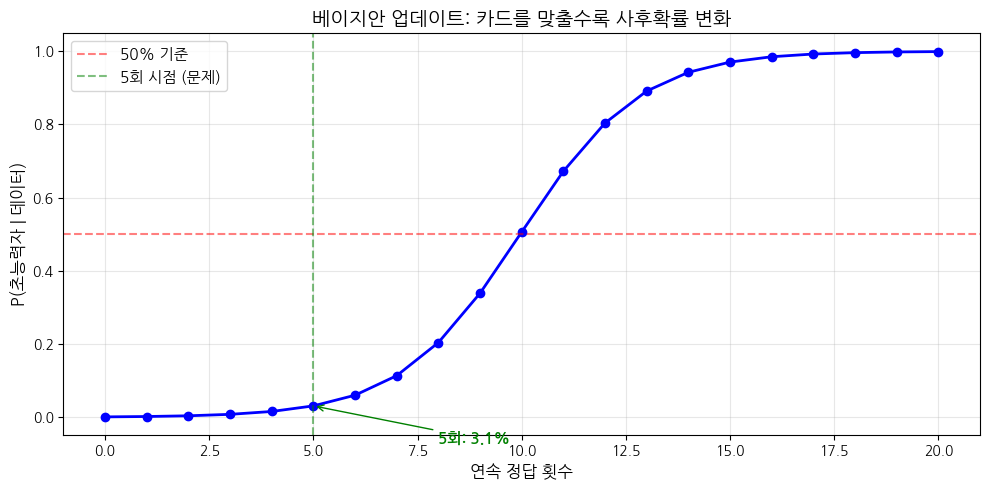

연속 정답 횟수별 사후확률:
  0회: 0.1000%
  1회: 0.1998%
  3회: 0.7944%
  5회: 3.1038%
  10회: 50.6179%
  15회: 97.0415%
  20회: 99.9048%


In [14]:
# ── 베이지안 업데이트 시뮬레이션: 카드를 더 맞출수록 사후확률 변화 ──
n_cards = 20
prior = 0.001
posteriors = [prior]

for i in range(1, n_cards + 1):
    likelihood_super = 1.0
    likelihood_normal = 0.5
    numerator = likelihood_super * posteriors[-1]
    denominator = numerator + likelihood_normal * (1 - posteriors[-1])
    posteriors.append(numerator / denominator)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(n_cards + 1), posteriors, 'bo-', linewidth=2, markersize=6)
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='50% 기준')
ax.axvline(x=5, color='green', linestyle='--', alpha=0.5, label='5회 시점 (문제)')
ax.set_xlabel('연속 정답 횟수', fontsize=12)
ax.set_ylabel('P(초능력자 | 데이터)', fontsize=12)
ax.set_title('베이지안 업데이트: 카드를 맞출수록 사후확률 변화', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# 5회 시점 표시
ax.annotate(f'5회: {posteriors[5]:.1%}', xy=(5, posteriors[5]),
            xytext=(8, posteriors[5]-0.1),
            arrowprops=dict(arrowstyle='->', color='green'),
            fontsize=11, color='green', fontweight='bold')

plt.tight_layout()
plt.show()

print("연속 정답 횟수별 사후확률:")
for i in [0, 1, 3, 5, 10, 15, 20]:
    print(f"  {i}회: {posteriors[i]:.4%}")

---
## 8. Bivariate Plot (슬라이드 62)
### 평균, 분산, 공분산 변경에 따른 분포 변화

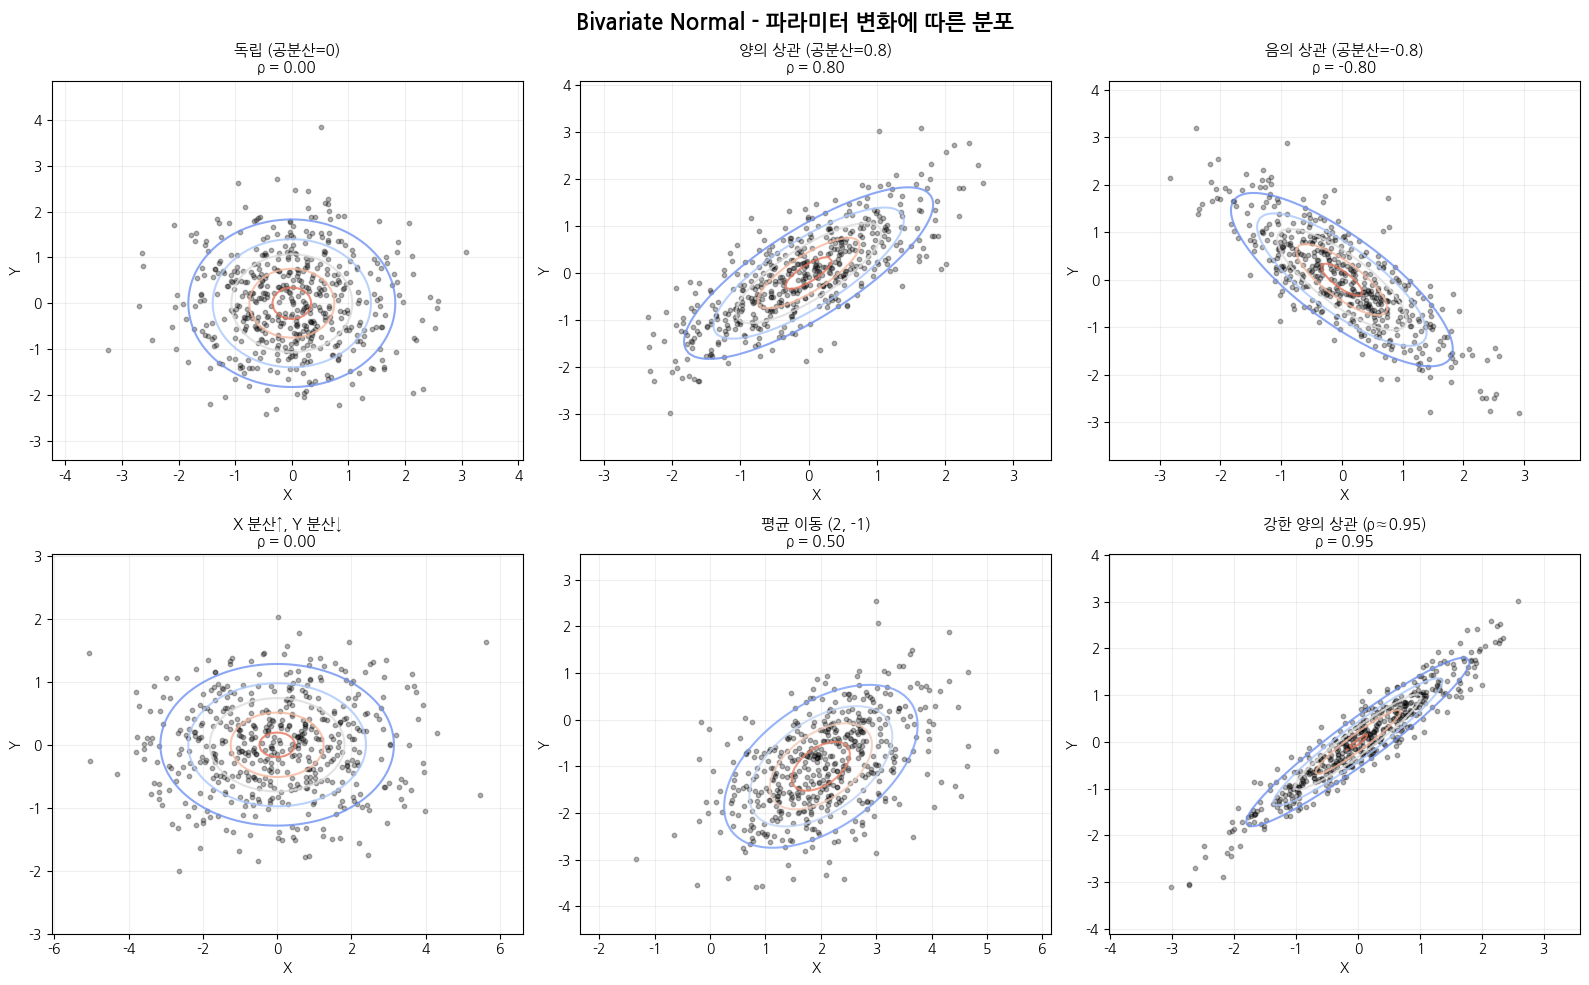

In [15]:
from scipy.stats import multivariate_normal

def plot_bivariate(mean, cov, title, ax):
    """이변량 정규분포 시각화"""
    # 데이터 생성
    data = np.random.multivariate_normal(mean, cov, 500)
    x, y = data[:, 0], data[:, 1]

    # 산점도 + 히트맵
    ax.scatter(x, y, alpha=0.3, s=10, color='black')

    # 등고선
    xg = np.linspace(x.min()-1, x.max()+1, 100)
    yg = np.linspace(y.min()-1, y.max()+1, 100)
    Xg, Yg = np.meshgrid(xg, yg)
    pos = np.dstack((Xg, Yg))
    rv = multivariate_normal(mean, cov)
    ax.contour(Xg, Yg, rv.pdf(pos), levels=5, cmap='coolwarm', alpha=0.8)

    # 상관계수 계산
    corr = cov[0][1] / np.sqrt(cov[0][0] * cov[1][1])
    ax.set_title(f'{title}\nρ = {corr:.2f}', fontsize=11)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.grid(True, alpha=0.2)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Bivariate Normal - 파라미터 변화에 따른 분포', fontsize=16, fontweight='bold')

configs = [
    ([0, 0], [[1, 0], [0, 1]], '독립 (공분산=0)'),
    ([0, 0], [[1, 0.8], [0.8, 1]], '양의 상관 (공분산=0.8)'),
    ([0, 0], [[1, -0.8], [-0.8, 1]], '음의 상관 (공분산=-0.8)'),
    ([0, 0], [[3, 0], [0, 0.5]], 'X 분산↑, Y 분산↓'),
    ([2, -1], [[1, 0.5], [0.5, 1]], '평균 이동 (2, -1)'),
    ([0, 0], [[1, 0.95], [0.95, 1]], '강한 양의 상관 (ρ≈0.95)'),
]

np.random.seed(42)
for ax, (mean, cov, title) in zip(axes.flat, configs):
    plot_bivariate(mean, cov, title, ax)

plt.tight_layout()
plt.show()

In [16]:
# ── 상관관계 계산 예시 ──
print("상관계수 계산 예시")
print("="*40)

np.random.seed(42)
mean = [0, 0]
cov = [[1, 0.7], [0.7, 1]]  # 공분산 = 0.7
data = np.random.multivariate_normal(mean, cov, 1000)

corr_matrix = np.corrcoef(data[:, 0], data[:, 1])
print(f"\n설정된 공분산 행렬: {cov}")
print(f"이론적 상관계수 ρ = 0.7 / √(1×1) = 0.7")
print(f"샘플 상관계수: {corr_matrix[0, 1]:.4f}")
print(f"\n→ 공분산이 클수록 두 변수는 같은 방향으로 움직이는 경향")

상관계수 계산 예시

설정된 공분산 행렬: [[1, 0.7], [0.7, 1]]
이론적 상관계수 ρ = 0.7 / √(1×1) = 0.7
샘플 상관계수: 0.6714

→ 공분산이 클수록 두 변수는 같은 방향으로 움직이는 경향


---
## 9. Long-Tail Distribution 시뮬레이션 (슬라이드 63~64)
### 유튜브 조회수, 파레토 분포, BA 네트워크

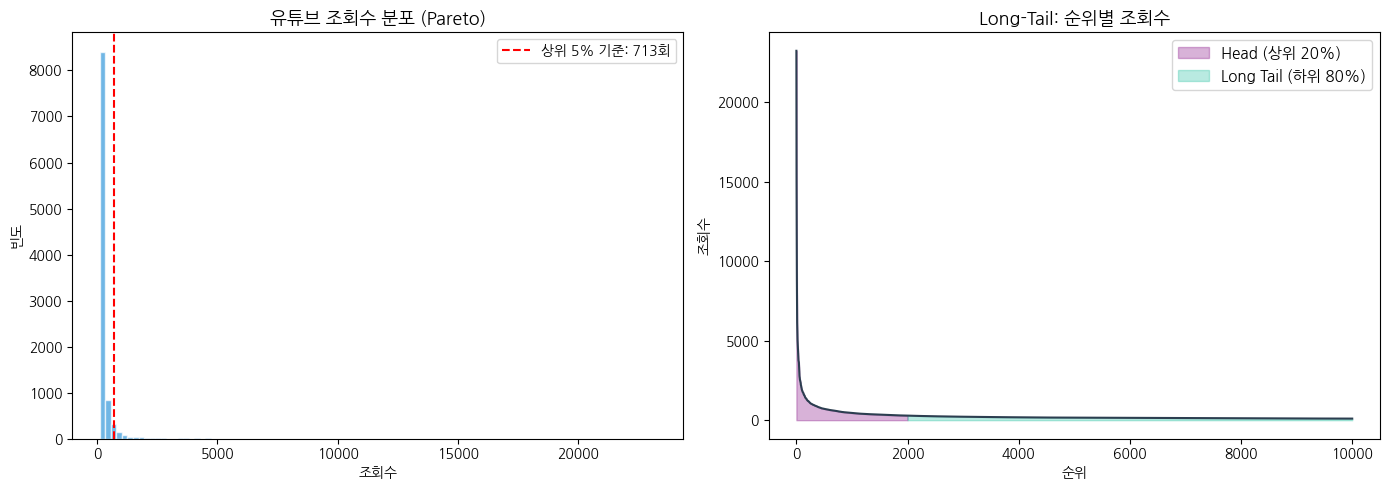

상위 20% 영상이 전체 조회수의 55.1%를 차지
하위 80% 영상이 전체 조회수의 44.9%를 차지


In [17]:
# ── 9-1) 유튜브 조회수 Long-Tail 시뮬레이션 ──
np.random.seed(42)

# Pareto 분포로 유튜브 조회수 시뮬레이션
n_videos = 10000
alpha = 1.5  # shape parameter
views = (np.random.pareto(alpha, n_videos) + 1) * 100  # 최소 100회
views_sorted = np.sort(views)[::-1]  # 내림차순

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램
axes[0].hist(views, bins=100, color='#3498db', edgecolor='white', alpha=0.7)
axes[0].set_xlabel('조회수')
axes[0].set_ylabel('빈도')
axes[0].set_title('유튜브 조회수 분포 (Pareto)', fontsize=13)
axes[0].axvline(x=np.percentile(views, 95), color='red', linestyle='--',
                label=f'상위 5% 기준: {np.percentile(views, 95):.0f}회')
axes[0].legend()

# 순위-조회수 그래프 (Long Tail)
ranks = np.arange(1, n_videos + 1)
axes[1].plot(ranks, views_sorted, color='#2c3e50', linewidth=1.5)
axes[1].fill_between(ranks[:int(n_videos*0.2)], views_sorted[:int(n_videos*0.2)],
                     alpha=0.3, color='purple', label='Head (상위 20%)')
axes[1].fill_between(ranks[int(n_videos*0.2):], views_sorted[int(n_videos*0.2):],
                     alpha=0.3, color='#1abc9c', label='Long Tail (하위 80%)')
axes[1].set_xlabel('순위')
axes[1].set_ylabel('조회수')
axes[1].set_title('Long-Tail: 순위별 조회수', fontsize=13)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

top20_share = views_sorted[:int(n_videos*0.2)].sum() / views.sum()
print(f"상위 20% 영상이 전체 조회수의 {top20_share:.1%}를 차지")
print(f"하위 80% 영상이 전체 조회수의 {1-top20_share:.1%}를 차지")

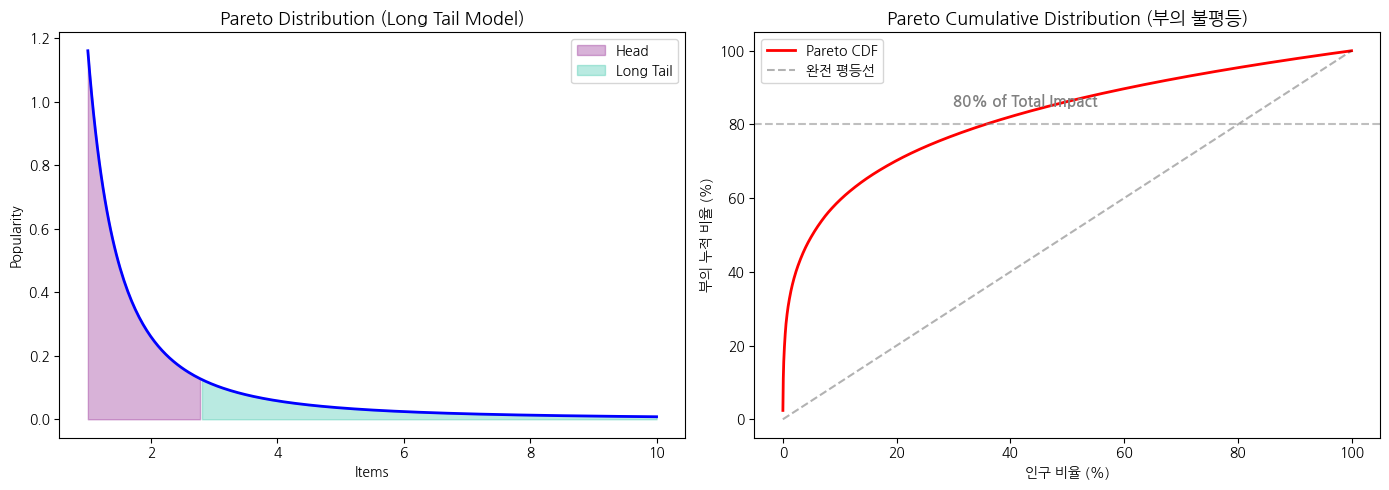


Pareto 80/20 법칙 검증:
  상위 20%가 전체 부의 70.2%를 보유


In [18]:
# ── 9-2) 부의 불평등 Pareto 80/20 실험 ──
np.random.seed(42)

n_people = 10000
wealth = np.random.pareto(1.16, n_people) + 1  # 파레토 분포
wealth_sorted = np.sort(wealth)[::-1]

# 누적 비율 계산
cumulative_wealth = np.cumsum(wealth_sorted) / wealth_sorted.sum()
population_pct = np.arange(1, n_people + 1) / n_people

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pareto PDF
x_range = np.linspace(1, 10, 300)
alpha_pareto = 1.16
pdf_vals = alpha_pareto / x_range**(alpha_pareto + 1)

axes[0].plot(x_range, pdf_vals, 'b-', linewidth=2)
axes[0].fill_between(x_range[:60], pdf_vals[:60], alpha=0.3, color='purple', label='Head')
axes[0].fill_between(x_range[60:], pdf_vals[60:], alpha=0.3, color='#1abc9c', label='Long Tail')
axes[0].set_xlabel('Items')
axes[0].set_ylabel('Popularity')
axes[0].set_title('Pareto Distribution (Long Tail Model)', fontsize=13)
axes[0].legend()

# CDF (로렌츠 곡선 스타일)
axes[1].plot(population_pct * 100, cumulative_wealth * 100, 'r-', linewidth=2, label='Pareto CDF')
axes[1].plot([0, 100], [0, 100], 'k--', alpha=0.3, label='완전 평등선')
axes[1].axhline(y=80, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('인구 비율 (%)')
axes[1].set_ylabel('부의 누적 비율 (%)')
axes[1].set_title('Pareto Cumulative Distribution (부의 불평등)', fontsize=13)
axes[1].legend()
axes[1].text(30, 85, '80% of Total Impact', fontsize=11, color='gray', fontweight='bold')

plt.tight_layout()
plt.show()

# 80/20 확인
top20_idx = int(n_people * 0.2)
top20_wealth = wealth_sorted[:top20_idx].sum() / wealth_sorted.sum()
print(f"\nPareto 80/20 법칙 검증:")
print(f"  상위 20%가 전체 부의 {top20_wealth:.1%}를 보유")

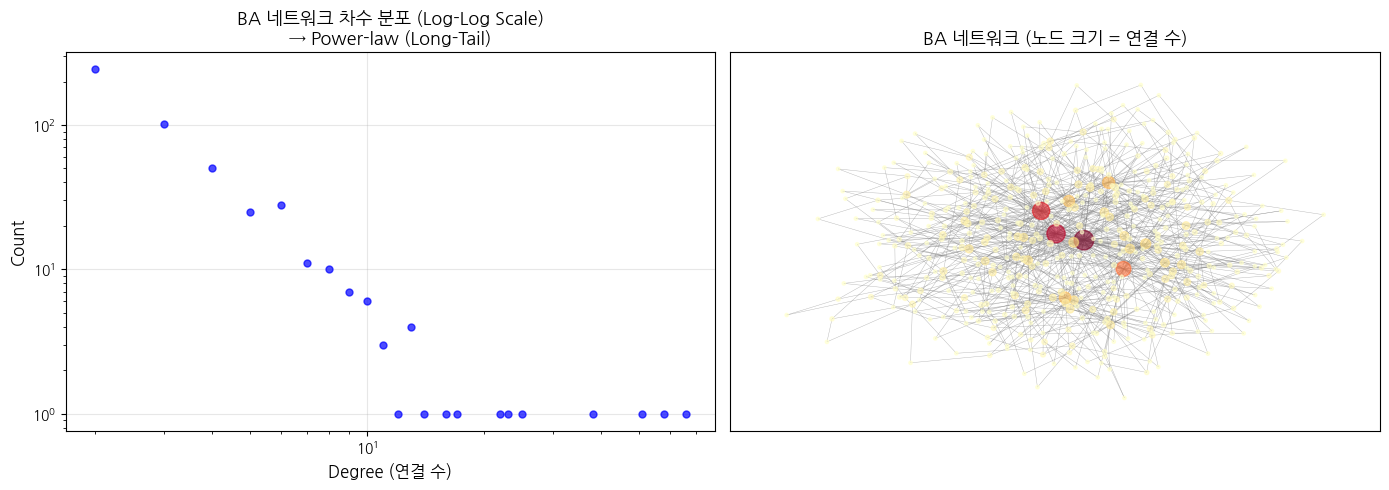

노드 수: 500, 엣지 수: 996
최대 차수(허브): 66, 평균 차수: 4.0

→ 소수의 허브 노드가 대부분의 연결을 가짐 = Long-Tail / Scale-Free 네트워크


In [19]:
# ── 9-3) Barabási-Albert 네트워크 성장 모델 ──
!pip install networkx -q
import networkx as nx

np.random.seed(42)

# BA 네트워크 생성
n_nodes = 500
m = 2  # 새 노드가 연결할 기존 노드 수
G = nx.barabasi_albert_graph(n_nodes, m, seed=42)

# 차수 분포
degrees = [d for n, d in G.degree()]
degree_counts = np.bincount(degrees)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 차수 분포 (Log-Log)
nonzero = degree_counts > 0
x_deg = np.arange(len(degree_counts))[nonzero]
y_deg = degree_counts[nonzero]
axes[0].loglog(x_deg, y_deg, 'bo', markersize=5, alpha=0.7)
axes[0].set_xlabel('Degree (연결 수)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('BA 네트워크 차수 분포 (Log-Log Scale)\n→ Power-law (Long-Tail)', fontsize=13)
axes[0].grid(True, alpha=0.3)

# 네트워크 시각화 (부분)
pos = nx.spring_layout(G, seed=42, k=0.3)
node_sizes = [d * 3 for _, d in G.degree()]
nx.draw_networkx(G, pos, ax=axes[1], node_size=node_sizes,
                 node_color=degrees, cmap='YlOrRd',
                 with_labels=False, edge_color='gray', alpha=0.6, width=0.3)
axes[1].set_title('BA 네트워크 (노드 크기 = 연결 수)', fontsize=13)

plt.tight_layout()
plt.show()

print(f"노드 수: {G.number_of_nodes()}, 엣지 수: {G.number_of_edges()}")
print(f"최대 차수(허브): {max(degrees)}, 평균 차수: {np.mean(degrees):.1f}")
print(f"\n→ 소수의 허브 노드가 대부분의 연결을 가짐 = Long-Tail / Scale-Free 네트워크")

---
## 10. Long-Tail과 불균형 데이터 (Imbalanced Data)
### 머신러닝에서의 문제와 해결

In [20]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# ── 불균형 데이터 생성 (95:5 비율) ──
X_imb, y_imb = make_classification(
    n_samples=2000, n_features=10, n_informative=5,
    weights=[0.95, 0.05], random_state=42, flip_y=0.01
)

X_tr, X_te, y_tr, y_te = train_test_split(X_imb, y_imb, test_size=0.3, random_state=42)

print("="*60)
print("불균형 데이터 문제 시연")
print("="*60)
print(f"\n클래스 분포: 다수 클래스={sum(y_imb==0)}, 소수 클래스={sum(y_imb==1)}")
print(f"비율: {sum(y_imb==0)/len(y_imb):.1%} vs {sum(y_imb==1)/len(y_imb):.1%}")

# ── 일반 모델 ──
model_normal = LogisticRegression(random_state=42, max_iter=1000)
model_normal.fit(X_tr, y_tr)
y_pred_normal = model_normal.predict(X_te)

print(f"\n[일반 모델 결과]")
print(classification_report(y_te, y_pred_normal, target_names=['다수(0)', '소수(1)']))

# ── class_weight='balanced' 모델 ──
model_balanced = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
model_balanced.fit(X_tr, y_tr)
y_pred_balanced = model_balanced.predict(X_te)

print(f"[Balanced 모델 결과 (class_weight='balanced')]")
print(classification_report(y_te, y_pred_balanced, target_names=['다수(0)', '소수(1)']))

print("→ 불균형 데이터에서는 소수 클래스의 recall이 매우 낮아질 수 있음")
print("  class_weight 조정, 오버샘플링(SMOTE), 언더샘플링 등으로 개선 가능")

불균형 데이터 문제 시연

클래스 분포: 다수 클래스=1892, 소수 클래스=108
비율: 94.6% vs 5.4%

[일반 모델 결과]
              precision    recall  f1-score   support

       다수(0)       0.95      1.00      0.98       573
       소수(1)       0.00      0.00      0.00        27

    accuracy                           0.95       600
   macro avg       0.48      0.50      0.49       600
weighted avg       0.91      0.95      0.93       600

[Balanced 모델 결과 (class_weight='balanced')]
              precision    recall  f1-score   support

       다수(0)       0.99      0.73      0.84       573
       소수(1)       0.12      0.78      0.21        27

    accuracy                           0.73       600
   macro avg       0.55      0.75      0.52       600
weighted avg       0.95      0.73      0.81       600

→ 불균형 데이터에서는 소수 클래스의 recall이 매우 낮아질 수 있음
  class_weight 조정, 오버샘플링(SMOTE), 언더샘플링 등으로 개선 가능


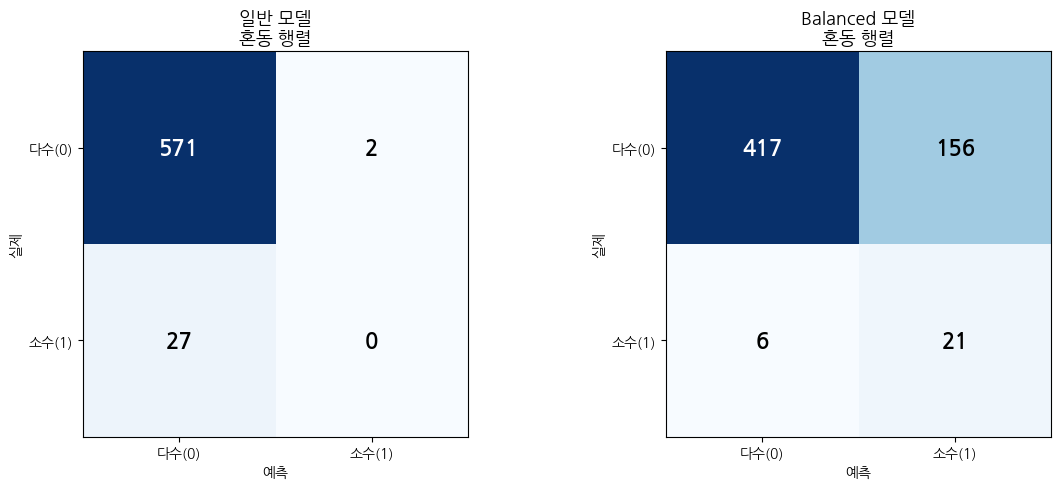

In [21]:
# ── 혼동 행렬 비교 시각화 ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in [
    (axes[0], y_pred_normal, '일반 모델'),
    (axes[1], y_pred_balanced, 'Balanced 모델')
]:
    cm = confusion_matrix(y_te, y_pred)
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_title(f'{title}\n혼동 행렬', fontsize=13)
    ax.set_xlabel('예측')
    ax.set_ylabel('실제')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['다수(0)', '소수(1)'])
    ax.set_yticklabels(['다수(0)', '소수(1)'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    fontsize=16, fontweight='bold',
                    color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.show()

---
## 정리

| 주제 | 핵심 개념 |
|------|----------|
| 조건부 확률 | P(X\|Y) - 한 변수의 값이 주어졌을 때 다른 변수의 분포 변화 |
| 베이즈 정리 | 사전확률 + 새로운 증거 → 사후확률 업데이트 |
| Survivorship Bias | 생존한 데이터만 분석하면 잘못된 결론에 도달 |
| 나이브 베이즈 | 각 특성이 독립이라 가정, 정규분포 PDF로 우도 계산 |
| Bayesian vs Frequentist | 확률을 '믿음의 정도'로 보느냐 vs '빈도'로 보느냐 |
| Long-Tail | 소수가 대부분을 차지하는 분포, 불균형 데이터 문제와 연결 |